# **Simple Panoramic Image**

**Course:** Signal and Image Processing  
**Academic Year:** 2025/2026  
**Student:** Irene Marrali    
**Images:** `boat1.jpg`, `boat3.jpg`.

## General Objective

The goal of this assignment is to create a **simple panoramic image** starting from two partially overlapping input images, `boat1.jpg` and `boat3.jpg`.

The procedure follows a simple manual pipeline:

* First, both images are imported as grayscale images.
*  Then, `boat3` is manually translated in order to align its overlapping region with the corresponding region in `boat1`. The best translation is found by visual inspection, using common visual elements in the two images as reference points.
* After the geometric alignment, a gamma correction is applied to `boat3` to make its brightness more consistent with `boat1`.
* Finally, the two images are placed into a larger canvas and merged into a single panoramic image. The overlapping region is handled using a **simple paste operation**, where the translated version of `boat3` overwrites the corresponding pixels of `boat1`.

This assignment illustrates that a digital image can be treated as a two-dimensional array of pixel values. Therefore, basic array operations can be used to shift, paste, adjust, and combine images.

## Initial Setup and Image Import
In this first section, the working environment is prepared. The two input images, `boat1.jpg` and `boat3.jpg` are uploaded and the required Python libraries are imported,

In [1]:
# Upload the required image files to the Colab environment.
# The expected files are:
# - boat1.jpg
# - boat3.jpg

from google.colab import files

uploaded = files.upload()

Saving boat3.jpg to boat3.jpg
Saving boat1.jpg to boat1.jpg


In [2]:
# Import the libraries needed for image loading, processing, and visualization.
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.exposure import adjust_gamma

These libraries provide the basic tools needed to treat the images as numerical arrays and to display the intermediate and final results.

The two images are now imported as **grayscale images.** This is done by setting `as_gray=True` when reading the files. After loading, the images are converted to **floating point format,** with pixel values in the range [0, 1].

In [3]:
# Load the two input images as grayscale images.
boat1 = io.imread("boat1.jpg", as_gray=True) # The parameter as_gray=True converts the images to grayscale during loading.
boat3 = io.imread("boat3.jpg", as_gray=True)

# Convert the images to floating point format.
# After this conversion, pixel values are represented in the range [0, 1].
boat1 = img_as_float(boat1)
boat3 = img_as_float(boat3)

# Store the height and width of each image.
h1, w1 = boat1.shape
h3, w3 = boat3.shape

# Print the image dimensions to check that the images were loaded correctly.
print("boat1 shape:", boat1.shape)
print("boat3 shape:", boat3.shape)

boat1 shape: (518, 778)
boat3 shape: (518, 778)


At this point, both images are represented as two-dimensional arrays. Each element of the array corresponds to the grayscale intensity of one pixel.

Before applying any transformation, the two original grayscale images are displayed side by side. This makes it easier to observe the partially overlapping content and to identify common visual reference points that will be useful for the manual alignment step.

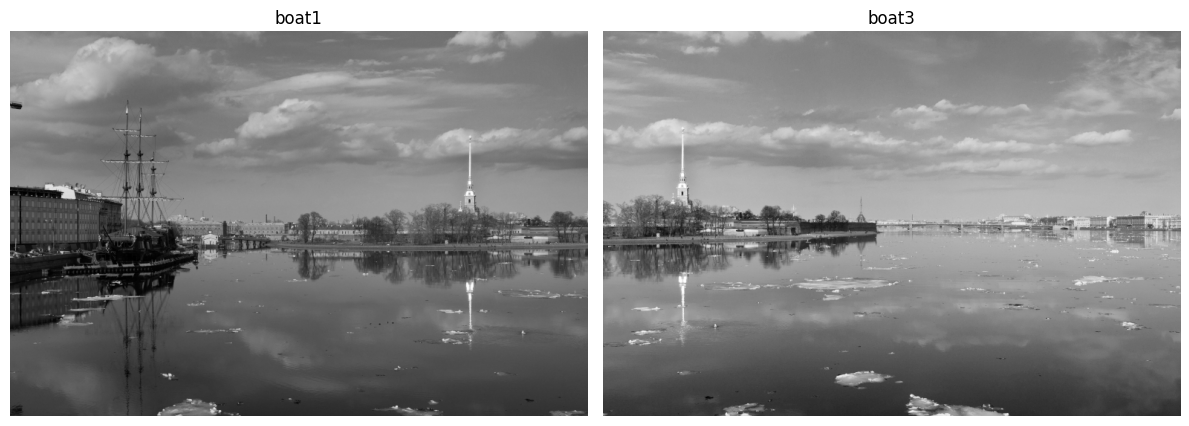

In [4]:
# Display the two grayscale images side by side.
plt.figure(figsize=(12, 5))  # the figure will be 12 inches wide and 5 inches high.

# Create the first subplot in a grid with 1 row and 2 columns.
plt.subplot(1, 2, 1)
plt.imshow(boat1, cmap="gray") # Display the first image using a grayscale colormap.
plt.title("boat1")  # Add a title above the first image.
plt.axis("off")  # Hide the x-axis and y-axis

# Create the second subplot in the same grid with 1 row and 2 columns.
plt.subplot(1, 2, 2)
plt.imshow(boat3, cmap="gray") # Display the second image using a grayscale colormap.
plt.title("boat3")  # Add a title above the second image.
plt.axis("off")  # Hide the x-axis and y-axis

plt.tight_layout()  # Automatically adjust the spacing between subplots.
plt.show() # Show the complete figure.

The visualization shows that the two images contain **partially overlapping content.** In particular, the church tower appears in both images and can be used as the main visual reference point to manually estimate the translation needed to align `boat3` with `boat1`.

The visualization also shows a difference in brightness intensity between the two images. For this reason, after the geometric alignment, a **gamma correction** will be applied to `boat3` in order to make its intensity more consistent with `boat1`.

## Manual translation and alignment
In this section, the best translation for aligning `boat3` with `boat1` is found manually. Since the two images contain partially overlapping content, `boat3` must be **shifted horizontally and vertically** until the common region matches the corresponding region in `boat1`.

The main visual reference used for the alignment is the church tower, which appears in both images. Its position and reflection in the water help to evaluate whether the two images are correctly aligned.

Before selecting the final translation, several candidate values are tested. Each pair `(x_offset, y_offset)` represents a possible translation of boat3 with respect to boat1.

* The parameter `x_offset `controls the horizontal shift of boat3;
* The parameter `y_offset` controls the vertical shift.

These values are chosen manually and evaluated by visual inspection.

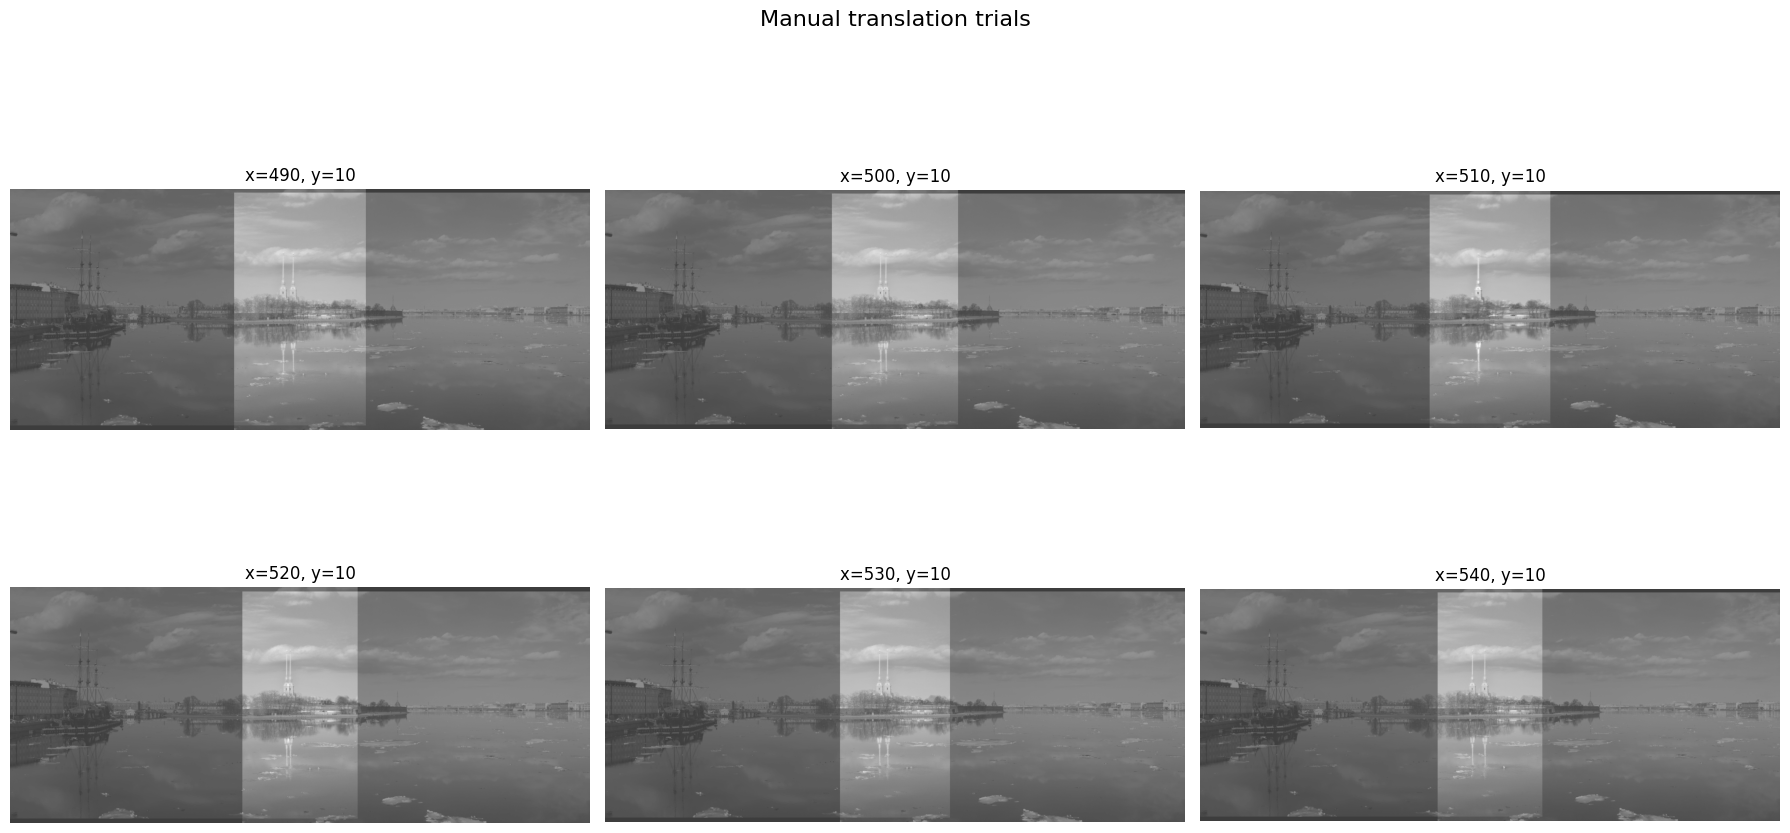

In [5]:
# In this step, different translation values are tested manually.
candidate_translations = [
    (490, 10),
    (500, 10),
    (510, 10),
    (520, 10),
    (530, 10),
    (540, 10)
]

# Create a figure to compare all candidate translations.
plt.figure(figsize=(18, 10))

# Loop over the candidate translation values.
for i, (x_offset, y_offset) in enumerate(candidate_translations):

    # Create a canvas large enough to contain both images.
    canvas_height = max(h1, y_offset + h3) # The canvas width depends on the vertical position of boat3.
    canvas_width = max(w1, x_offset + w3)  # The canvas height depends on the horizontal position of boat3.

    # Create two empty canvases:
    # one for boat1 and one for the translated boat3.
    canvas1 = np.zeros((canvas_height, canvas_width))
    canvas3 = np.zeros((canvas_height, canvas_width))

    # Paste boat1 at the origin.
    canvas1[0:h1, 0:w1] = boat1

    # Paste boat3 using the candidate translation.
    # This operation applies the manual shift to boat3.
    canvas3[y_offset:y_offset+h3, x_offset:x_offset+w3] = boat3

    # Display the two images superimposed with transparency.
    # This makes it easier to visually check the alignment.
    plt.subplot(2, 3, i + 1)
    plt.imshow(canvas1, cmap="gray", alpha=0.6)
    plt.imshow(canvas3, cmap="gray", alpha=0.4)
    plt.title(f"x={x_offset}, y={y_offset}")
    plt.axis("off")

# Add a general title to the figure.
plt.suptitle("Manual translation trials", fontsize=16)
plt.tight_layout()  # Automatically adjust the spacing between subplots.
plt.show()  # Show the comparison figure.

The comparison of the different trials makes it possible to visually evaluate which translation gives the best alignment. Among the tested values, **the best visual alignment** is obtained with:

* `x_offset = 510`
* `y_offset = 10`

These values are selected because the tower appears better aligned in the overlapping region.

After comparing the candidate translations, the selected values are applied to `boat3`. This creates two aligned canvases: one containing `boat1` and one containing the translated version of `boat3`.

In [6]:
# These values were chosen manually by visual inspection.
# boat3 has to be shifted to the right so that the tower overlaps.

x_offset = 510
y_offset = 10

# Create a canvas large enough to contain both images.
canvas_height = max(h1, y_offset + h3)
canvas_width = max(w1, x_offset + w3)

# Create two empty canvases with the same dimensions.
canvas1 = np.zeros((canvas_height, canvas_width))
canvas3 = np.zeros((canvas_height, canvas_width))

# Paste boat1 at the origin. It is used as the reference image.
canvas1[0:h1, 0:w1] = boat1

# Paste boat3 after applying the manual translation
canvas3[y_offset:y_offset+h3, x_offset:x_offset+w3] = boat3

At this point, the selected translation has been applied. The two images are now positioned in the same coordinate system, but they are still stored in two separate canvases. This is useful because it allows the alignment to be checked before creating the final panorama.

The following visualization shows boat1 and the translated boat3 superimposed with transparency. This makes the overlapping region visible and allows a final visual check of the manual alignment.

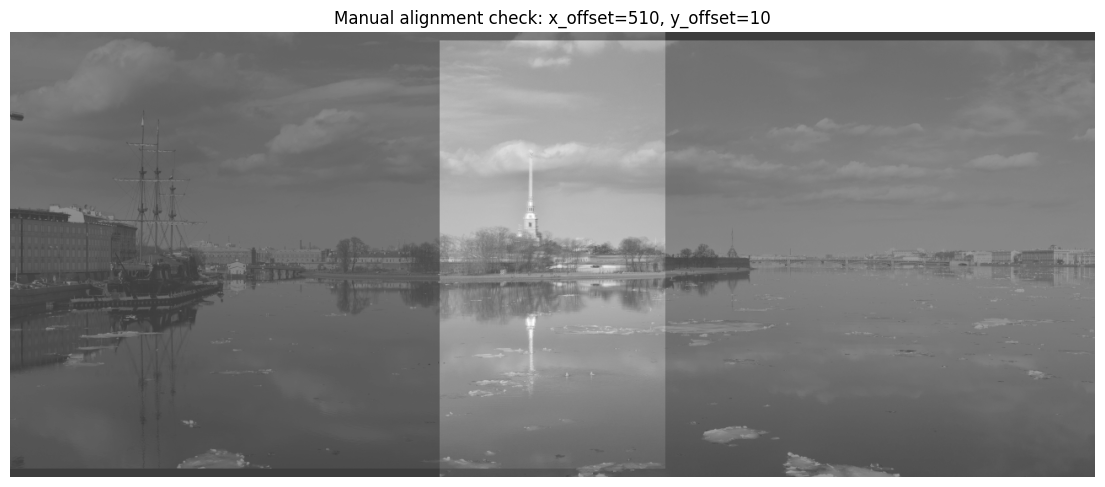

In [7]:
#The two canvases are displayed on top of each other with transparency.
plt.figure(figsize=(14, 6))

# Display boat1 with partial transparency.
plt.imshow(canvas1, cmap="gray", alpha=0.6)
# Display the translated boat3 with partial transparency.
plt.imshow(canvas3, cmap="gray", alpha=0.4)

plt.title(f"Manual alignment check: x_offset={x_offset}, y_offset={y_offset}")
plt.axis("off")
plt.show() # Show the alignment result.

The visualization confirms that the translated `boat3` is aligned with `boat1` in the overlapping region. **The selected translation will be kept fixed** and reused in the following steps, where gamma correction and image merging will be applied.

## Gamma Correction

After the geometric alignment, the next step is to adjust the brightness intensity of `boat3`. From the initial visualization, the two images do not have exactly the same intensity distribution. Since the final panorama is created by combining the two images, this difference may produce a visible discontinuity in the overlapping region.

Gamma correction is applied to `boat3` in order to make its brightness more consistent with `boat1`. The gamma value is selected manually by testing different values and comparing the results visually.

In general:
* a gamma value < 1 makes the image brighter;
* a gamma value > 1 makes the image darker.

First, different gamma values are applied to `boat3`. The purpose is to visually compare the corrected versions and select the one that best matches the brightness of `boat1`.

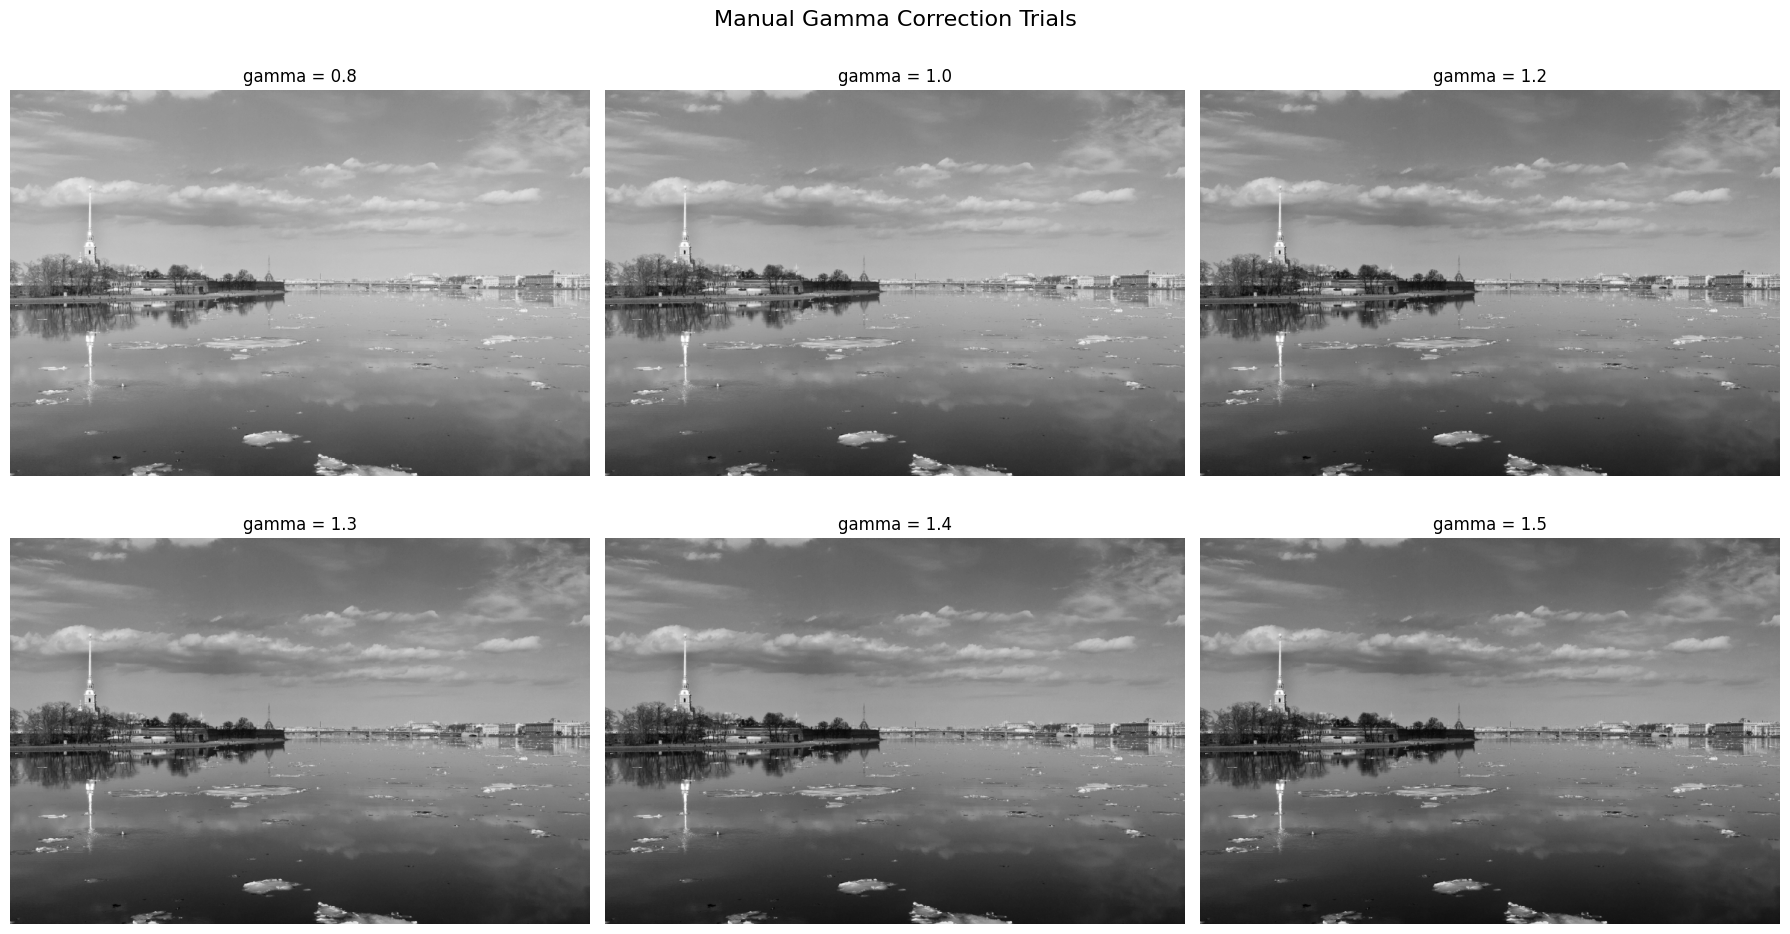

In [8]:
# In this step, different gamma values are tested manually.
# The goal is to make the brightness of boat3 more similar to boat1.

# Candidate gamma values tested by visual inspection.
gamma_values = [0.8, 1.0, 1.2, 1.3, 1.4, 1.5]

# Create a figure to compare the effect of different gamma values.
plt.figure(figsize=(18, 10))

# Loop over the candidate gamma values.
for i, gamma in enumerate(gamma_values):

    # Apply gamma correction to boat3.
    boat3_gamma_trial = adjust_gamma(boat3, gamma=gamma)

    # Display each gamma-corrected image in a subplot.
    plt.subplot(2, 3, i + 1)
    plt.imshow(boat3_gamma_trial, cmap="gray")
    plt.title(f"gamma = {gamma}")
    plt.axis("off")

# Add a general title to the figure.
plt.suptitle("Manual Gamma Correction Trials", fontsize=16)

# Adjust the spacing between subplots.
plt.tight_layout()

# Show the comparison figure.
plt.show()

To choose the best gamma value, it is useful to compare the corrected version of `boat3` directly with `boat1` in the aligned position. The same manual translation selected in the previous section is used.

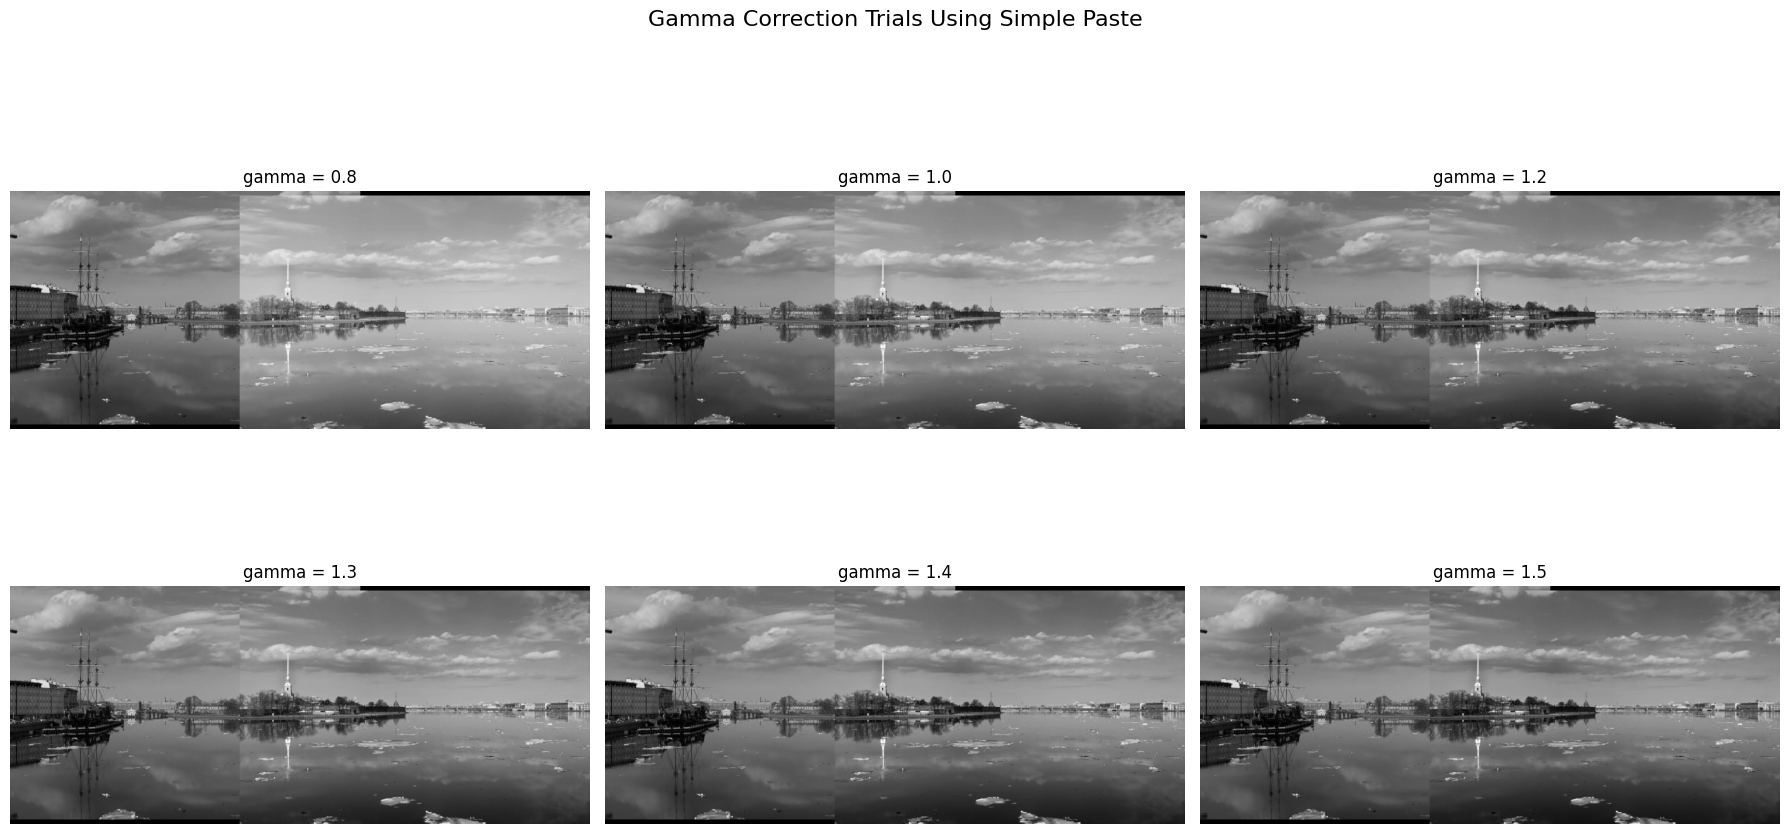

In [9]:
# Different gamma values are tested by creating temporary panoramas.

from skimage.exposure import adjust_gamma

# Use the selected manual translation from the previous section
x_offset = 510
y_offset = 10

# Candidate gamma values tested manually
gamma_values = [0.8, 1.0, 1.2, 1.3, 1.4, 1.5]

plt.figure(figsize=(18, 10))

for i, gamma in enumerate(gamma_values):

    # Apply gamma correction to boat3
    boat3_gamma_trial = adjust_gamma(boat3, gamma=gamma)

    # Create a canvas large enough to contain both images
    canvas_height = max(h1, y_offset + h3)
    canvas_width = max(w1, x_offset + w3)

    # Create an empty temporary panorama
    panorama_trial = np.zeros((canvas_height, canvas_width))

    # Paste boat1 first
    panorama_trial[0:h1, 0:w1] = boat1

    # Paste gamma-corrected boat3 using the selected translation
    # In the overlapping region, boat3 overwrites boat1
    panorama_trial[y_offset:y_offset+h3, x_offset:x_offset+w3] = boat3_gamma_trial

    # Display the temporary panorama
    plt.subplot(2, 3, i + 1)
    plt.imshow(panorama_trial, cmap="gray")
    plt.title(f"gamma = {gamma}")
    plt.axis("off")

plt.suptitle("Gamma Correction Trials Using Simple Paste", fontsize=16)
plt.tight_layout()
plt.show()

Since the images are pasted directly into the same canvas, this comparison makes it easier to evaluate the brightness difference in a realistic way.

Lower gamma values, such as` 0.8` and `1.0`, make `boat3` appear too bright compared to boat1. Higher gamma values, such as `1.4` and `1.5`, make `boat3` darker, but the result becomes slightly too strong. Among the tested values, `gamma = 1.3` provides the best visual compromise, because it reduces the brightness difference between the two images without making `boat3` excessively dark.

For this reason, `gamma = 1.3` is selected and will be applied to `boat3` in the final panorama.



## Final Panorama Creation

In this final section, the selected manual translation and the selected gamma correction are applied together to produce the final panoramic image.

The values chosen in the previous sections are:

- `x_offset = 510`
- `y_offset = 10`
- `gamma_value = 1.3`

The final panorama is created using **a simple paste operation.** First, `boat1` is placed in the canvas. Then, the gamma-corrected version of `boat3` is pasted using the selected translation. In the overlapping region, `boat3` overwrites the corresponding pixels of `boat1`, following the simple image pasting approach required by the assignment.

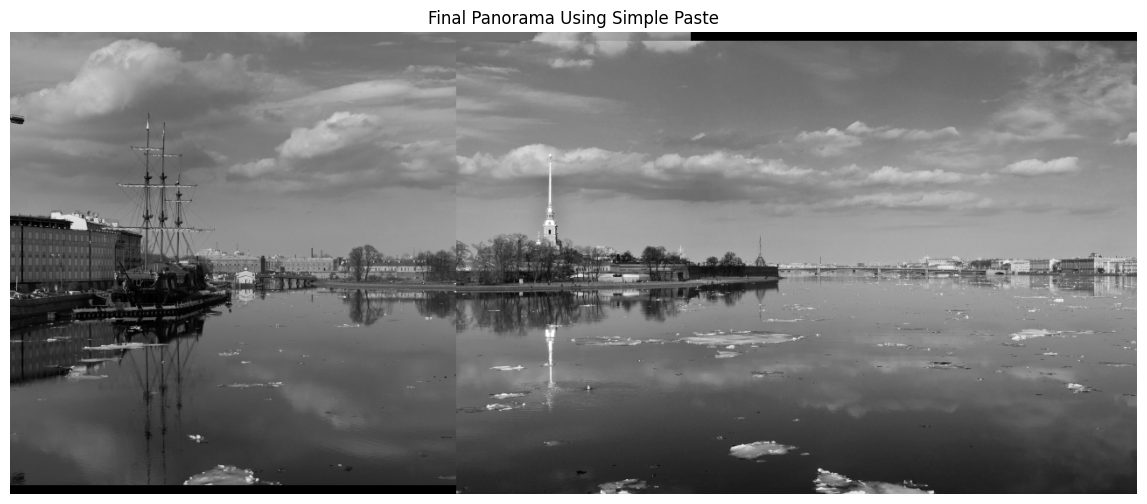

In [10]:
# The selected translation and gamma correction are applied.
# boat1 is pasted first, then boat3 is pasted on top.

x_offset = 510
y_offset = 10
gamma_value = 1.3

# Apply the selected gamma correction to boat3
boat3_gamma = adjust_gamma(boat3, gamma=gamma_value)

# Create a canvas large enough to contain both images
canvas_height = max(h1, y_offset + h3)
canvas_width = max(w1, x_offset + w3)

# Create the final panoramic canvas
panorama = np.zeros((canvas_height, canvas_width))

# Paste boat1 at the origin
panorama[0:h1, 0:w1] = boat1

# Paste the translated and gamma-corrected boat3
# In the overlapping region, boat3 overwrites boat1
panorama[y_offset:y_offset+h3, x_offset:x_offset+w3] = boat3_gamma

# Display the final panorama
plt.figure(figsize=(16, 6))
plt.imshow(panorama, cmap="gray")
plt.title("Final Panorama Using Simple Paste")
plt.axis("off")
plt.show()

The final result shows a simple panoramic image obtained by manually aligning and pasting the two input images. The church tower and its reflection appear in the overlapping region, confirming that the selected translation provides a reasonable alignment between `boat1` and `boat3`.

The gamma correction also improves the visual consistency between the two images. However, a slight vertical transition is still visible where `boat3` is pasted over `boat1`. This is expected because the method uses a simple paste operation, without more advanced blending techniques.

The result could be further improved using additional image processing operations, such as **intensity normalization, histogram matching, or linear blending in the overlapping region.** These techniques could reduce the visible discontinuity between the two images and make the panorama smoother.